# 2.1 — Oversampling with Augmentation for Class Imbalance

Apply **repeat-factor-style oversampling** with per-copy augmentation to force the model to see more minority-class (`no-helmet`, `no-vest`) examples.

**Strategy:**
- Images containing `no-helmet` (class 1): duplicated 10×, each copy augmented differently
- Images containing `no-vest` (class 2): duplicated 3×, each copy augmented differently
- All other images kept as-is
- Combined with YOLOv8's built-in `copy_paste` augmentation and focal loss at training time

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib opencv-python-headless albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.5 MB/s eta 0:00:00


In [1]:
# @title Mount Drive or clone repo
import os
from pathlib import Path
import sys

# Option A: Mount Drive
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT_DIR = Path("/content/drive/MyDrive/AlGear")

# Option B: Clone from GitHub
!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")

fatal: destination path 'AlGear' already exists and is not an empty directory.
Project root: /content/AlGear


In [2]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""

from algear.config import ROBOFLOW_DIR, ROBOFLOW_API_KEY
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Dataset at: {ROBOFLOW_DIR}")

2026-06-22 13:22:00.576 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Dataset at: /content/AlGear/data/raw/construction-safety-gsnvb


In [3]:
# @title Download dataset (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-22 13:22:02.273 | INFO     | algear.dataset:download_roboflow:33 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 5181.96it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-22 13:22:37.599 | SUCCESS  | algear.dataset:download_roboflow:37 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Class Distribution Before Oversampling

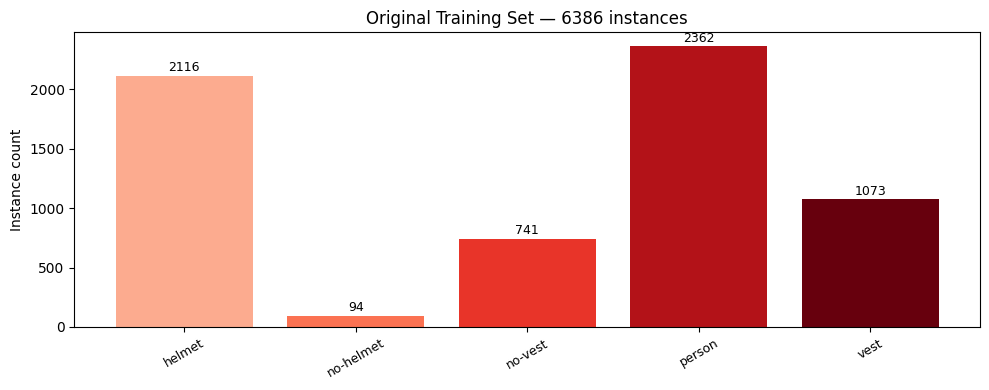

Imbalance ratio (helmet:no-helmet):  22.5x
Imbalance ratio (vest:no-vest):      1.4x


In [4]:
# @title Visualise original class distribution
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import yaml

from algear.config import ROBOFLOW_DIR

with open(ROBOFLOW_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]

def count_instances(lbl_dir) -> Counter:
    c = Counter()
    for lbl in sorted(lbl_dir.glob("*.txt")):
        with open(lbl) as f:
            for line in f:
                c[int(line.strip().split()[0])] += 1
    return c

train_counts = count_instances(ROBOFLOW_DIR / "train" / "labels")
total = sum(train_counts.values())

fig, ax = plt.subplots(figsize=(10, 4))
names = [class_names[i] for i in range(len(class_names))]
counts = [train_counts.get(i, 0) for i in range(len(class_names))]
colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(names)))

bars = ax.bar(names, counts, color=colors)
ax.set_title(f"Original Training Set — {total} instances")
ax.set_ylabel("Instance count")
ax.tick_params(axis="x", rotation=30, labelsize=9)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(c), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {counts[0] / max(counts[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {counts[4] / max(counts[2], 1):.1f}x")

## 2. Generate Oversampled Dataset

We scan the training labels, find every image that contains `no-helmet` (class 1) or `no-vest` (class 2), and create augmented copies.

Each copy gets a **different random augmentation** drawn from:
- Brightness / contrast shift
- Hue / saturation / value jitter
- Gaussian blur
- Gaussian noise
- CLAHE (local contrast enhancement)
- Gamma correction
- Grayscale conversion

These are all **box-preserving** transforms — label coordinates stay valid.

In [5]:
# @title Run oversampling
from algear.dataset import oversample

oversample(
    labels_dir=ROBOFLOW_DIR / "train" / "labels",
    img_dir=ROBOFLOW_DIR / "train" / "images",
    output_dir=PROJECT_DIR / "data" / "processed" / "construction-site-safety-oversampled",
    multiplier_no_helmet=10,
    multiplier_no_vest=3,
)

2026-06-22 13:22:38.081 | INFO     | algear.dataset:oversample:85 - Class 1 (no-helmet): 49 images, multiplier=10, ~441 augmented copies
2026-06-22 13:22:38.082 | INFO     | algear.dataset:oversample:85 - Class 2 (no-vest): 390 images, multiplier=3, ~780 augmented copies
2026-06-22 13:22:38.082 | INFO     | algear.dataset:oversample:91 - Creating oversampled dataset in /content/AlGear/data/processed/construction-site-safety-oversampled


Oversampling: 100%|██████████| 997/997 [00:20<00:00, 48.50files/s]

2026-06-22 13:23:00.098 | INFO     | algear.modeling.oversample:create_oversampled_dataset:116 - Oversampling complete: 997 originals + 1161 augmented = 2158 total
2026-06-22 13:23:00.101 | SUCCESS  | algear.dataset:oversample:112 - Oversampled dataset ready at /content/AlGear/data/processed/construction-site-safety-oversampled


## 3. Class Distribution After Oversampling

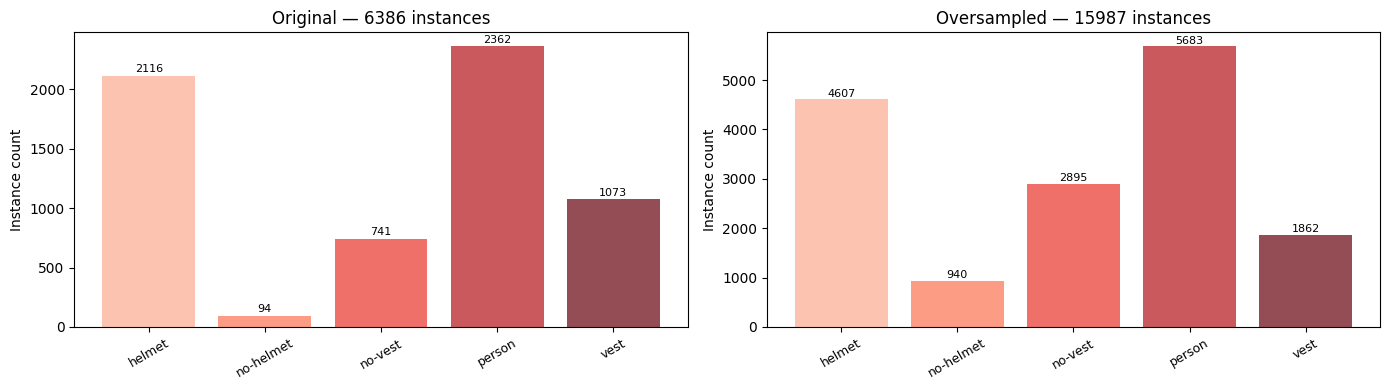

Imbalance ratio (helmet:no-helmet):  4.9x
Imbalance ratio (vest:no-vest):      0.6x


In [6]:
# @title Visualise oversampled class distribution
oversampled_dir = PROJECT_DIR / "data" / "processed" / "construction-site-safety-oversampled"

os_counts = count_instances(oversampled_dir / "train" / "labels")
os_total = sum(os_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

os_counts_list = [os_counts.get(i, 0) for i in range(len(class_names))]

ax1.bar(names, counts, color=colors, alpha=0.7)
ax1.set_title(f"Original — {total} instances")
ax1.set_ylabel("Instance count")
ax1.tick_params(axis="x", rotation=30, labelsize=9)

ax2.bar(names, os_counts_list, color=colors, alpha=0.7)
ax2.set_title(f"Oversampled — {os_total} instances")
ax2.set_ylabel("Instance count")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

for ax, cts in [(ax1, counts), (ax2, os_counts_list)]:
    for bar, c in zip(ax.containers[0], cts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(c), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {os_counts_list[0] / max(os_counts_list[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {os_counts_list[4] / max(os_counts_list[2], 1):.1f}x")

## 4. Train with Oversampled Data + Augmentation

Two layers of imbalance mitigation are stacked:
1. **Pre-augmented oversampling** (just generated)
2. **`copy_paste=0.3`** — YOLOv8 pastes object instances across images during training

YOLOv8's built-in mosaic, flip, HSV jitter, scale, and translate augmentations are also active (default), stacking on top of the pre-augmented copies.

In [7]:
# @title Train YOLOv8s with imbalance handling
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from algear.modeling.train import train_yolov8

results = train_yolov8(
    model_name="yolov8s.pt",
    name="oversample-10x",
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    output_dir=PROJECT_DIR / "models",
    oversample_data=True,
    copy_paste=0.3,
)

Using device: 0
GPU: Tesla T4
2026-06-22 13:23:06.061 | INFO     | algear.modeling.train:train_yolov8:36 - Using oversampled dataset: /content/AlGear/data/processed/construction-site-safety-oversampled/data.yaml
2026-06-22 13:23:06.229 | INFO     | algear.modeling.train:train_yolov8:45 - Training YOLOv8s on /content/AlGear/data/processed/construction-site-safety-oversampled/data.yaml
2026-06-22 13:23:06.229 | INFO     | algear.modeling.train:train_yolov8:46 - Epochs=50, imgsz=640, batch=16, device=0
2026-06-22 13:23:06.229 | INFO     | algear.modeling.train:train_yolov8:56 - Imbalance strategies: repeat-factor oversampling, copy_paste=0.3
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_l

## 5. Evaluate on Test Set

In [8]:
# @title Evaluate best model on test split
from algear.modeling.train import evaluate

# Find the latest trained model
import glob
model_dirs = sorted(PROJECT_DIR.glob("models/*/weights/best.pt"))
latest_model = model_dirs[-1] if model_dirs else None
print(f"Evaluating: {latest_model}")

metrics = evaluate(
    model_path=latest_model,
    data_yaml=ROBOFLOW_DIR / "data.yaml",
    split="test",
    device=device,
)

Evaluating: /content/AlGear/models/baseline/weights/best.pt
2026-06-22 13:54:31.296 | INFO     | algear.modeling.train:evaluate:105 - Evaluating /content/AlGear/models/baseline/weights/best.pt on test split
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 24.9±14.0 MB/s, size: 55.2 KB)
val: Scanning /content/AlGear/data/raw/construction-safety-gsnvb/test/labels... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 561.1it/s 0.2s
val: New cache created: /content/AlGear/data/raw/construction-safety-gsnvb/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5it/s 4.1s
                   all         90        623      0.745      0.793      0.761      0.379
                helmet         82        195      0.823      0.933      0.926      0

## 6. Results Summary

Compare against the baseline (no imbalance handling):

| Class | Baseline mAP@50 | Oversampled mAP@50 |
|---|---|---|
| helmet | 0.929   | 0.926|
| no-helmet | 0.592 | 0.583 |
| no-vest | 0.630  | 0.602 |
| person | 0.890   | 0.873 |
| vest | 0.850     | 0.823 |
| **Overall** | **0.778** | 0.761 |

In [9]:
from google.colab import files
files.download(str(PROJECT_DIR / "models" / "baseline" / "weights" / "best.pt"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>